In [78]:
import matplotlib.pyplot as plt
from sklearn.preprocessing import RobustScaler
#from sklearn.preprocessing import StandardScaler
import numpy as np

import warnings
warnings.filterwarnings('ignore')
import pandas as pd
from sklearn.cluster import HDBSCAN
import astropy.units as u
# from zero_point import zpt
from tqdm import tqdm
import os
os.getcwd()

'c:\\Users\\Bruno\\Desktop\\Personal-projects-1\\Proyectos de Astronomía\\Laboratorio 3'

In [79]:
df = pd.read_csv("M41_query_result_full.csv").dropna(subset='pmra') # full gaia sample for one cluster
df = df.dropna(subset=['pmra','pmdec','parallax','bp_rp','phot_g_mean_mag'])
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 27590 entries, 0 to 28195
Data columns (total 15 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   random_index         27590 non-null  int64  
 1   source_id            27590 non-null  int64  
 2   ra                   27590 non-null  float64
 3   dec                  27590 non-null  float64
 4   parallax             27590 non-null  float64
 5   parallax_over_error  27590 non-null  float64
 6   pmdec                27590 non-null  float64
 7   pmdec_error          27590 non-null  float64
 8   pmra                 27590 non-null  float64
 9   pmra_error           27590 non-null  float64
 10  ruwe                 27590 non-null  float64
 11  phot_g_mean_mag      27590 non-null  float64
 12  phot_bp_mean_mag     27590 non-null  float64
 13  phot_rp_mean_mag     27590 non-null  float64
 14  bp_rp                27590 non-null  float64
dtypes: float64(13), int64(2)
memory usage: 3.

In [80]:
#clustering_on = ['ra','dec','pmra','pmdec','parallax']
clustering_on = ['pmra','pmdec','parallax', 'bp_rp', 'phot_g_mean_mag']
data = df[clustering_on]
features = data
data = RobustScaler().fit_transform(data)

In [81]:
#hd = HDBSCAN(min_cluster_size=20, min_samples=5, metric='mahalanobis', metric_params={'V': np.cov(data, rowvar=False)}).fit(data)
hd = HDBSCAN(min_cluster_size=100, min_samples=10, metric='euclidean').fit(data)

from sklearn.metrics import silhouette_samples, silhouette_score

In [82]:
labels = hd.labels_ 
df['label_hb'] = labels
for i in list(set(labels)):
    print('{} {}'.format(i,len(df[(df['label_hb'] == i)])))
    
unique_labels = np.unique(labels)

# mapa de colores
cmap = plt.cm.get_cmap('tab10', len(unique_labels))

# diccionario label -> color
color_map = {lab: cmap(i) for i, lab in enumerate(unique_labels)}

0 7349
1 1118
-1 19123


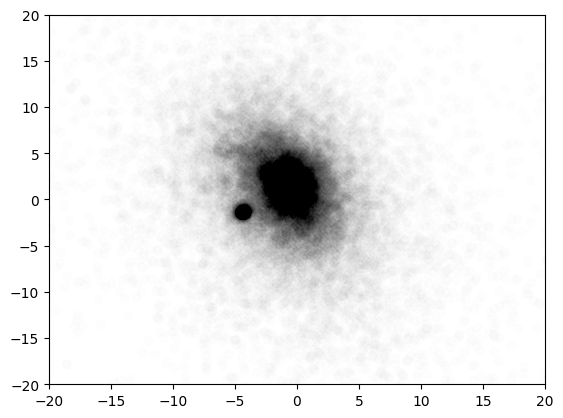

In [83]:
#VPD
plt.scatter(df['pmra'], df['pmdec'],c='k',alpha=0.008)
plt.xlim(-20, 20)
plt.ylim(-20, 20)
plt.show()

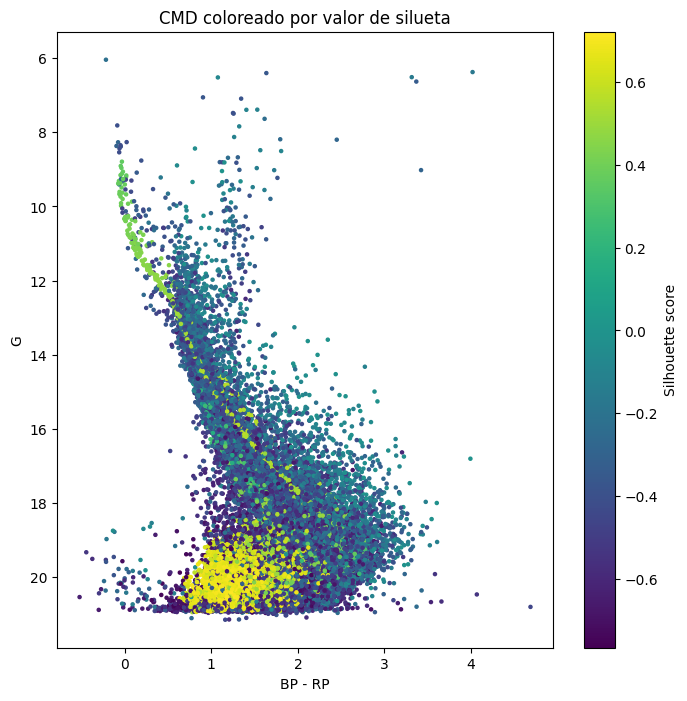

In [84]:
x = silhouette_samples(features, labels)
sil = x

plt.figure(figsize=(8,8))
sc = plt.scatter(features['bp_rp'],features['phot_g_mean_mag'],c=sil,cmap='viridis',s=5)
plt.gca().invert_yaxis()
plt.xlabel("BP - RP")
plt.ylabel("G")
plt.title("CMD coloreado por valor de silueta")
plt.colorbar(sc,label="Silhouette score")
plt.show()

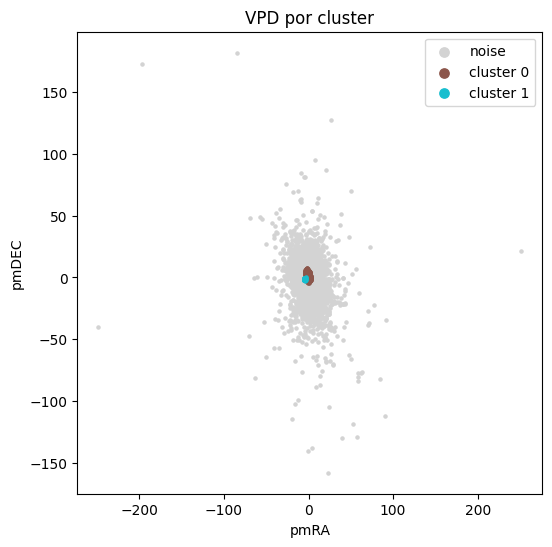

In [85]:
plt.figure(figsize=(6,6))

for lab in unique_labels:

    cond = df['label_hb'] == lab
    
    if lab == -1:
        color = 'lightgray'
        label = 'noise'
    else:
        color = color_map[lab]
        label = f'cluster {lab}'
    
    plt.scatter(df['pmra'][cond],
                df['pmdec'][cond],
                s=5,
                color=color,
                label=label)

plt.xlabel("pmRA")
plt.ylabel("pmDEC")
plt.title("VPD por cluster")
plt.legend(markerscale=3)
plt.show()

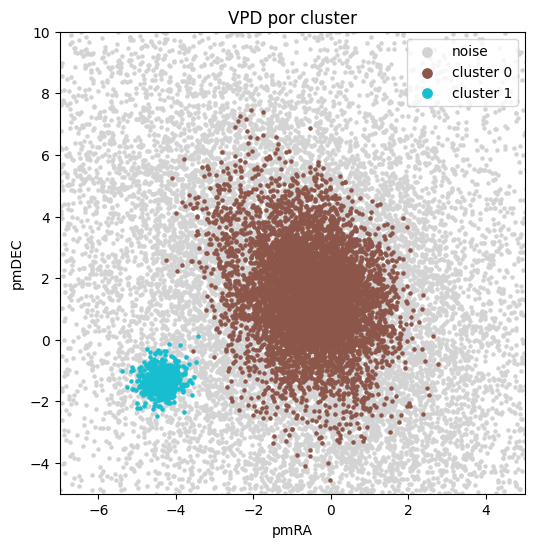

In [86]:
plt.figure(figsize=(6,6))

for lab in unique_labels:

    cond = df['label_hb'] == lab
    
    if lab == -1:
        color = 'lightgray'
        label = 'noise'
    else:
        color = color_map[lab]
        label = f'cluster {lab}'
    
    plt.scatter(df['pmra'][cond],
                df['pmdec'][cond],
                s=5,
                color=color,
                label=label)

plt.xlabel("pmRA")
plt.ylabel("pmDEC")
plt.xlim(-7,5)
plt.ylim(-5,10)
plt.title("VPD por cluster")
plt.legend(markerscale=3)
plt.show()

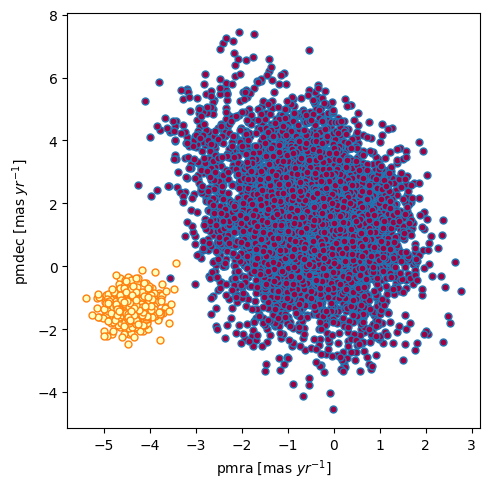

In [87]:
unique_labels = set(labels)
colors = [plt.cm.Spectral(each) for each in np.linspace(0, 1, len(unique_labels))]

plt.figure(figsize=(5,5))
for i, j in zip(list(unique_labels), colors):
    if i != -1:
        condition = (df['label_hb'] == i)
        plt.plot(df['pmra'][condition], df['pmdec'][condition], 
         markerfacecolor = tuple(j),marker = 'o', linestyle='None',markersize = 5, alpha = 1)
plt.xlabel("pmra [mas $yr^{-1}$]")
plt.ylabel("pmdec [mas $yr^{-1}$]")
plt.tight_layout()
plt.show() 

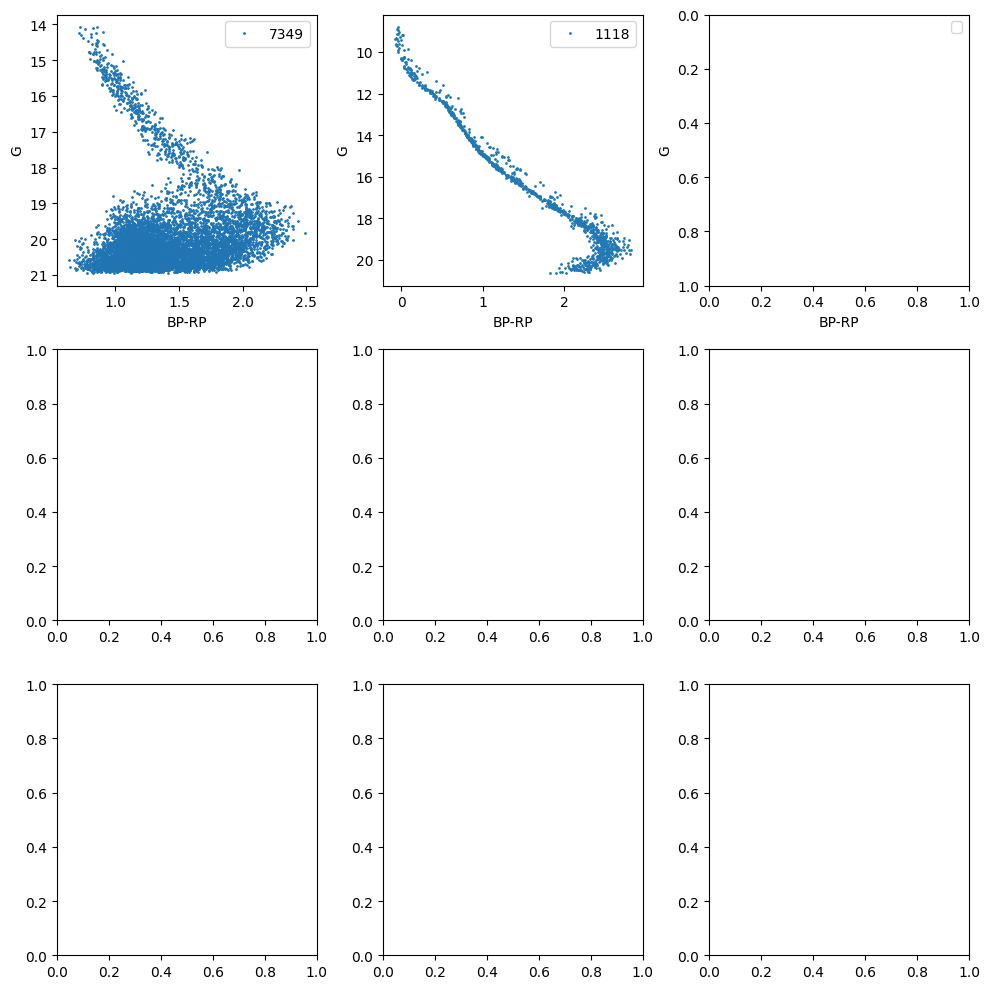

In [88]:
fig, axes = plt.subplots(3, 3, figsize=(10,10))

for i, j, ax in zip(list(unique_labels), colors, axes.flat):
    if i != -1:
        condition = (df['label_hb'] == i)
        ax.plot(df['phot_bp_mean_mag'][condition] - df['phot_rp_mean_mag'][condition], df['phot_g_mean_mag'][condition], 
         markerfacecolor = tuple(j), marker='o', linestyle='None', markersize=1, label=f'{len(df[condition])}')
    ax.set_xlabel("BP-RP")
    ax.set_ylabel("G")
    ax.invert_yaxis()
    ax.legend()

fig.tight_layout()
plt.show() 

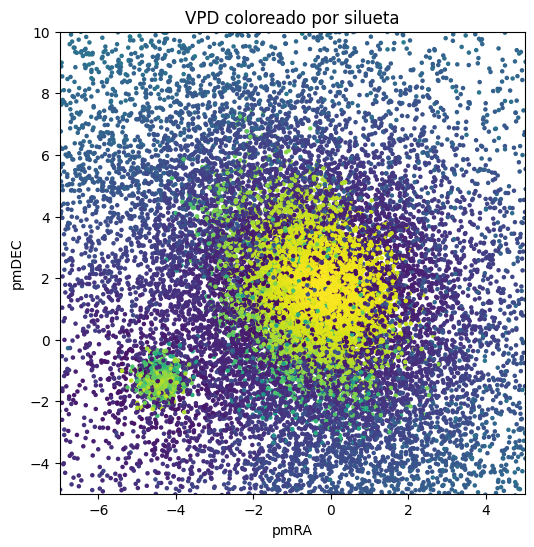

In [89]:
plt.figure(figsize=(6,6))

plt.scatter(features['pmra'], features['pmdec'], c=sil, cmap='viridis', s=5)

plt.xlabel("pmRA")
plt.ylabel("pmDEC")
plt.xlim(-7, 5)
plt.ylim(-5, 10)
plt.title("VPD coloreado por silueta")
plt.colorbar(sc,label="Silhouette score")
plt.show()

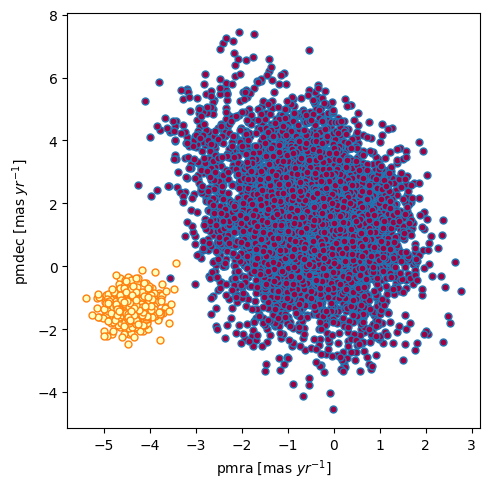

In [90]:
unique_labels = set(labels)
colors = [plt.cm.Spectral(each) for each in np.linspace(0, 1, len(unique_labels))]

plt.figure(figsize=(5,5))
for i, j in zip(list(unique_labels), colors):
    if i != -1:
        condition = (df['label_hb'] == i)
        plt.plot(df['pmra'][condition], df['pmdec'][condition], 
         markerfacecolor = tuple(j),marker = 'o', linestyle='None',markersize = 5, alpha = 1)
plt.xlabel("pmra [mas $yr^{-1}$]")
plt.ylabel("pmdec [mas $yr^{-1}$]")
plt.tight_layout()
plt.show() 

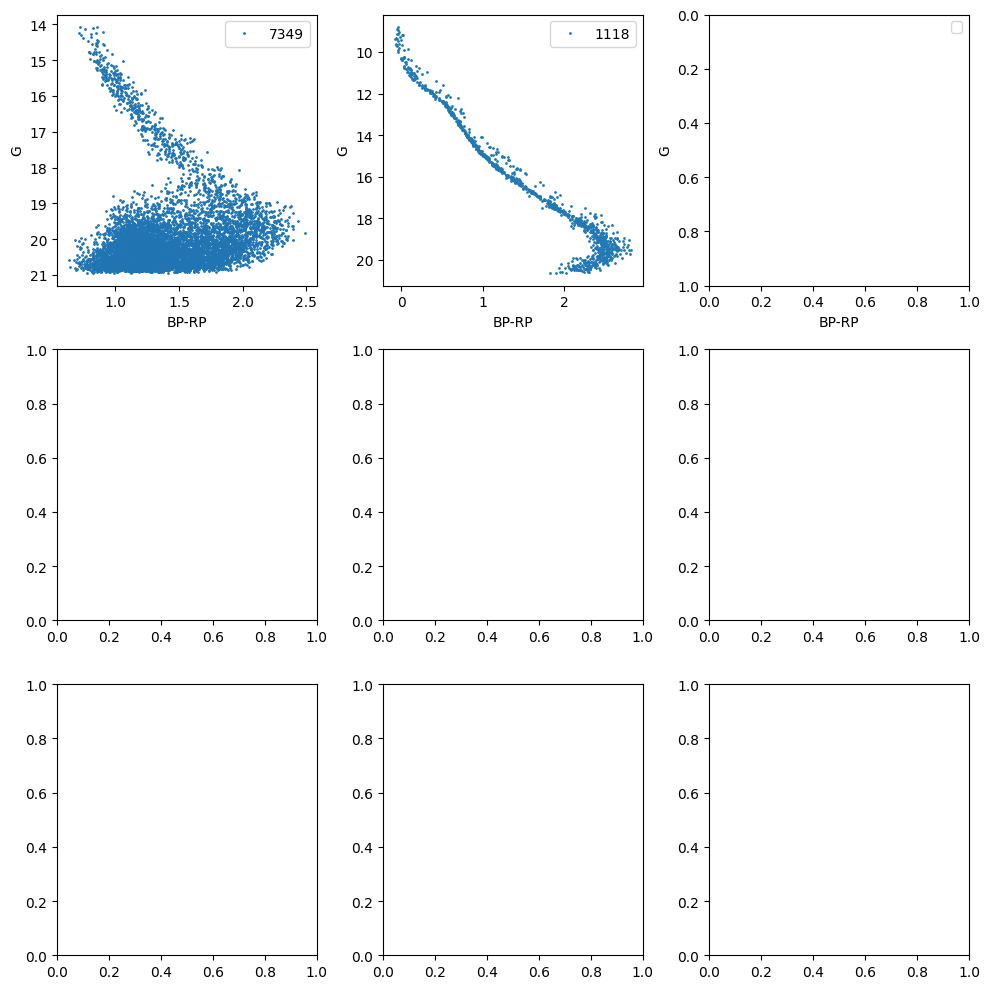

In [91]:
fig, axes = plt.subplots(3, 3, figsize=(10,10))

for i, j, ax in zip(list(unique_labels), colors, axes.flat):
    if i != -1:
        condition = (df['label_hb'] == i)
        ax.plot(df['phot_bp_mean_mag'][condition] - df['phot_rp_mean_mag'][condition], df['phot_g_mean_mag'][condition], 
         markerfacecolor = tuple(j), marker='o', linestyle='None', markersize=1, label=f'{len(df[condition])}')
    ax.set_xlabel("BP-RP")
    ax.set_ylabel("G")
    ax.invert_yaxis()
    ax.legend()

fig.tight_layout()
plt.show() 